In [2]:
import pandas as pd

In [6]:
prices = pd.read_csv(
    "data/AAPL_MSFT_KO_2020-01-01_2026-01-01_adjusted.csv",
    index_col=0,
    parse_dates=True,
)

prices.head()

,AAPL,MSFT,KO
Date,,,
2020-01-02,72.271538,151.544266,45.141270
2020-01-03,71.568909,149.657257,44.895000
2020-01-06,72.139206,150.044083,44.878574
2020-01-07,71.799919,148.676041,44.533798
2020-01-08,72.954895,151.044174,44.615887


In [4]:
normalised_prices = prices / prices.iloc[0] * 100

normalised_prices.head()

,AAPL,MSFT,KO
Date,,,
2020-01-02,100.000000,100.000000,100.000000
2020-01-03,99.027793,98.754814,99.454448
2020-01-06,99.816896,99.010069,99.418060
2020-01-07,99.347435,98.107335,98.654288
2020-01-08,100.945541,99.670003,98.836136


<Axes: title={'center': 'Normalised stock prices'}, xlabel='Date', ylabel='Value of an initial 100'>

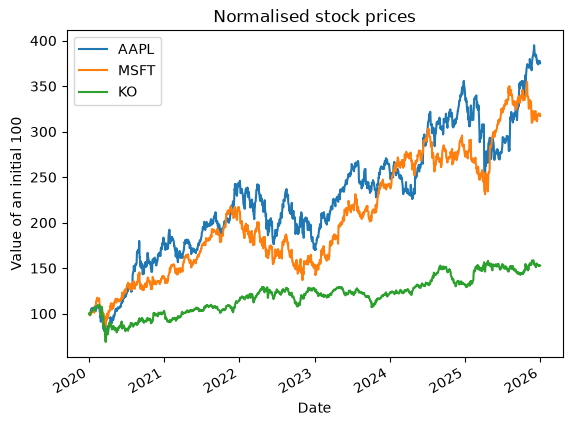

In [8]:
normalised_prices.plot(
    # figsize=(10, 6),
    title="Normalised stock prices",
    ylabel="Value of an initial 100",
    xlabel="Date",
)

In [14]:
daily_returns = prices.pct_change(fill_method=None).dropna()
daily_returns.head(-10)

,AAPL,MSFT,KO
Date,,,
2020-01-03,-0.009722,-0.012452,-0.005456
2020-01-06,0.007969,0.002585,-0.000366
2020-01-07,-0.004703,-0.009118,-0.007682
2020-01-08,0.016086,0.015928,0.001843
2020-01-09,0.021241,0.012493,0.018215
...,...,...,...
2025-12-10,0.005772,-0.027357,0.001712
2025-12-11,-0.002690,0.010260,-0.015667
2025-12-12,0.000899,-0.010218,0.020402


In [10]:
train_returns = daily_returns.loc[daily_returns.index < "2025-01-01"]
test_returns = daily_returns.loc[daily_returns.index >= "2025-01-01"]

In [15]:
annualised_volatility = train_returns.std() * (252 ** 0.5)
correlation = train_returns.corr()
covariance = train_returns.cov()

display(annualised_volatility, correlation, covariance)

AAPL    0.316786
MSFT    0.304972
KO      0.208001
dtype: float64

,AAPL,MSFT,KO
AAPL,1.000000,0.748327,0.439975
MSFT,0.748327,1.000000,0.434174
KO,0.439975,0.434174,1.000000


,AAPL,MSFT,KO
AAPL,0.000398,0.000287,0.000115
MSFT,0.000287,0.000369,0.000109
KO,0.000115,0.000109,0.000172


***

In [19]:
import numpy as np
from scipy.optimize import minimize

covariance = train_returns.cov()

def portfolio_variance(weights):
    return weights @ covariance.to_numpy() @ weights

In [28]:
n_assets = len(covariance.columns)

equal_weights = np.full(n_assets, 1 / n_assets)

constraints = {
    "type": "eq",
    "fun": lambda weights: weights.sum() - 1,
}

bounds = [(0, 1)] * n_assets

In [30]:
result = minimize(
    portfolio_variance,
    x0=equal_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000},
)

if not result.success:
    raise RuntimeError(result.message)

optimal_weights_slsqp = pd.Series(
    result.x,
    index=covariance.columns,
    name="Weight",
)

# display(optimal_weights.to_frame().style.format("{:.2%}"))

In [ ]:
result = minimize(
    portfolio_variance,
    x0=equal_weights,
    method="COBYQA",
    bounds=bounds,
    constraints=constraints,
    options={"final_tr_radius": 1e-10, "feasibility_tol": 1e-10, "maxiter": 1000},
)

if not result.success:
    raise RuntimeError(result.message)

optimal_weights_cobyqa = pd.Series(
    result.x,
    index=covariance.columns,
    name="Weight",
)

In [32]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, Bounds, LinearConstraint

cov_matrix = covariance.to_numpy()
n_assets = len(covariance.columns)

equal_weights = np.full(n_assets, 1 / n_assets)

def portfolio_variance(weights):
    return weights @ cov_matrix @ weights

def variance_gradient(weights):
    return 2 * cov_matrix @ weights

def variance_hessian(weights):
    return 2 * cov_matrix

bounds = Bounds(
    np.zeros(n_assets),
    np.ones(n_assets),
)

constraints = LinearConstraint(
    np.ones((1, n_assets)),
    lb=1,
    ub=1,
)

result = minimize(
    portfolio_variance,
    x0=equal_weights,
    method="trust-constr",
    jac=variance_gradient,
    hess=variance_hessian,
    bounds=bounds,
    constraints=constraints,
    options={
        "gtol": 1e-12,
        "xtol": 1e-12,
        "barrier_tol": 1e-12,
        "maxiter": 1000,
    },
)

if not result.success:
    raise RuntimeError(result.message)

optimal_weights_trust_constr = pd.Series(
    result.x,
    index=covariance.columns,
    name="Weight",
)


In [33]:
print("slsqp:")
display(optimal_weights_slsqp.to_frame().style.format("{:.2%}"))

print("cobyqa:")
display(optimal_weights_cobyqa.to_frame().style.format("{:.2%}"))

print("trust-constr:")
display(optimal_weights_trust_constr.to_frame().style.format("{:.2%}"))


slsqp:


,Weight
AAPL,6.65%
MSFT,14.53%
KO,78.82%


cobyqa:


,Weight
AAPL,6.66%
MSFT,14.52%
KO,78.82%


trust-constr:


,Weight
AAPL,6.65%
MSFT,14.53%
KO,78.82%


Wanted to try different methods of minimizing, only these three can handle bounds and equality constraints directly.